## Import necessary libraries

In [5]:
from google.colab import files
uploaded = files.upload()
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
import os

Saving Crime_Data.xlsx to Crime_Data (1).xlsx


## Loading datasets

In [10]:
os.path.exists("Crime_Data.xlsx")

True

In [13]:
df = pd.read_excel("/content/Crime_Data (1).xlsx", engine="openpyxl")
df.head()

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
0,5741943,HN549294,2007-08-25 09:22:18,074XX N ROGERS AVE,560,ASSAULT,SIMPLE,OTHER,False,False,...,49.0,1.0,08A,NaN,NaN,2007,2015-08-17 15:03:40,NaN,NaN,NaN
1,25953,JE240540,2021-05-24 15:06:00,020XX N LARAMIE AVE,110,HOMICIDE,FIRST DEGREE MURDER,STREET,True,False,...,36.0,19.0,01A,1141387.0,1913179.0,2021,2023-11-18 15:39:49,41.917838,-87.755969,"(41.917838056, -87.755968972)"
2,26038,JE279849,2021-06-26 09:24:00,062XX N MC CORMICK RD,110,HOMICIDE,FIRST DEGREE MURDER,PARKING LOT,True,False,...,50.0,13.0,01A,1152781.0,1941458.0,2021,2023-11-18 15:39:49,41.995219,-87.713355,"(41.995219444, -87.713354912)"
3,13279676,JG507211,2023-11-09 07:30:00,019XX W BYRON ST,620,BURGLARY,UNLAWFUL ENTRY,APARTMENT,False,False,...,47.0,5.0,5,1162518.0,1925906.0,2023,2023-11-18 15:39:49,41.952345,-87.677975,"(41.952345086, -87.677975059)"
4,13274752,JG501049,2023-11-12 07:59:00,086XX S COTTAGE GROVE AVE,454,BATTERY,"AGGRAVATED P.O. - HANDS, FISTS, FEET, NO / MIN...",SMALL RETAIL STORE,True,False,...,6.0,44.0,08B,1183071.0,1847869.0,2023,2023-12-09 15:41:24,41.737751,-87.604856,"(41.737750767, -87.604855911)"


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 549999 entries, 0 to 549998
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   ID                    549999 non-null  int64         
 1   Case Number           549999 non-null  object        
 2   Date                  549999 non-null  datetime64[ns]
 3   Block                 549999 non-null  object        
 4   IUCR                  549999 non-null  object        
 5   Primary Type          549999 non-null  object        
 6   Description           549999 non-null  object        
 7   Location Description  548326 non-null  object        
 8   Arrest                549999 non-null  bool          
 9   Domestic              549999 non-null  bool          
 10  Beat                  549999 non-null  int64         
 11  District              549999 non-null  int64         
 12  Ward                  213674 non-null  float64       
 13 

In [15]:
df.columns

Index(['ID', 'Case Number', 'Date', 'Block', 'IUCR', 'Primary Type',
       'Description', 'Location Description', 'Arrest', 'Domestic', 'Beat',
       'District', 'Ward', 'Community Area', 'FBI Code', 'X Coordinate',
       'Y Coordinate', 'Year', 'Updated On', 'Latitude', 'Longitude',
       'Location'],
      dtype='object')

## Convert Data Type

In [16]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Month'] = df['Date'].dt.month
df['Hour'] = df['Date'].dt.hour
df['Updated On'].head()
df['Updated On'] = pd.to_datetime(df['Updated On'], errors='coerce')
df['Updated On Year'] = df['Updated On'].dt.year
df['Updated On Month'] = df['Updated On'].dt.month
df['Updated On Hour'] = df['Updated On'].dt.hour

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 549999 entries, 0 to 549998
Data columns (total 27 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   ID                    549999 non-null  int64         
 1   Case Number           549999 non-null  object        
 2   Date                  549999 non-null  datetime64[ns]
 3   Block                 549999 non-null  object        
 4   IUCR                  549999 non-null  object        
 5   Primary Type          549999 non-null  object        
 6   Description           549999 non-null  object        
 7   Location Description  548326 non-null  object        
 8   Arrest                549999 non-null  bool          
 9   Domestic              549999 non-null  bool          
 10  Beat                  549999 non-null  int64         
 11  District              549999 non-null  int64         
 12  Ward                  213674 non-null  float64       
 13 

## Handling Null Values

In [18]:
df.isna().sum()

,0
ID,0
Case Number,0
Date,0
Block,0
IUCR,0
Primary Type,0
Description,0
Location Description,1673
Arrest,0
Domestic,0


In [19]:
df = df.dropna(subset=['Location Description', 'Ward', 'Community Area','X Coordinate','Y Coordinate','Latitude','Longitude','Location'])
df.isna().sum()

,0
ID,0
Case Number,0
Date,0
Block,0
IUCR,0
Primary Type,0
Description,0
Location Description,0
Arrest,0
Domestic,0


In [20]:
df.shape

(207594, 27)

## Temporal Analysis
Crime Trends Over Time

### Number of Crimes per Year

In [21]:
crime_by_year = df.groupby('Year').size().reset_index(name='Count')
fig_1 = px.bar(crime_by_year,x='Year',y='Count',title=f'Number of Crimes Per Year',color_discrete_sequence=px.colors.sequential.Viridis,height=500, width=1000)
fig_1.show()

### Number of Crimes per Month

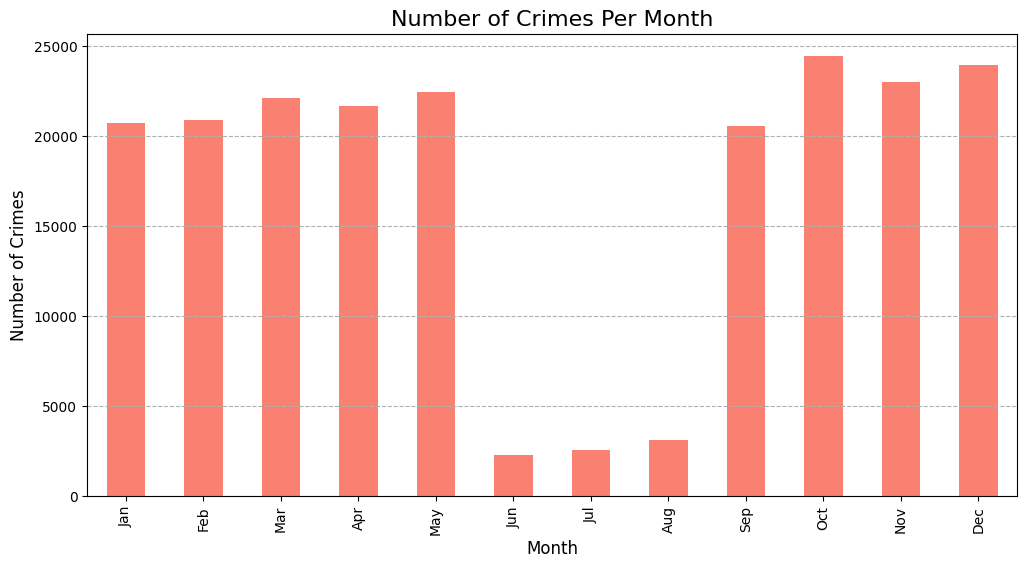

In [22]:
crime_by_month = df.groupby('Month').size()
plt.figure(figsize=(12, 6))
crime_by_month.plot(kind='bar', color='salmon')
plt.title('Number of Crimes Per Month', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of Crimes', fontsize=12)
plt.xticks(range(12),['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(axis='y', linestyle='--')
plt.show()

### Number of Crimes per Day

<ipython-input-23-ef21e2c59112>:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




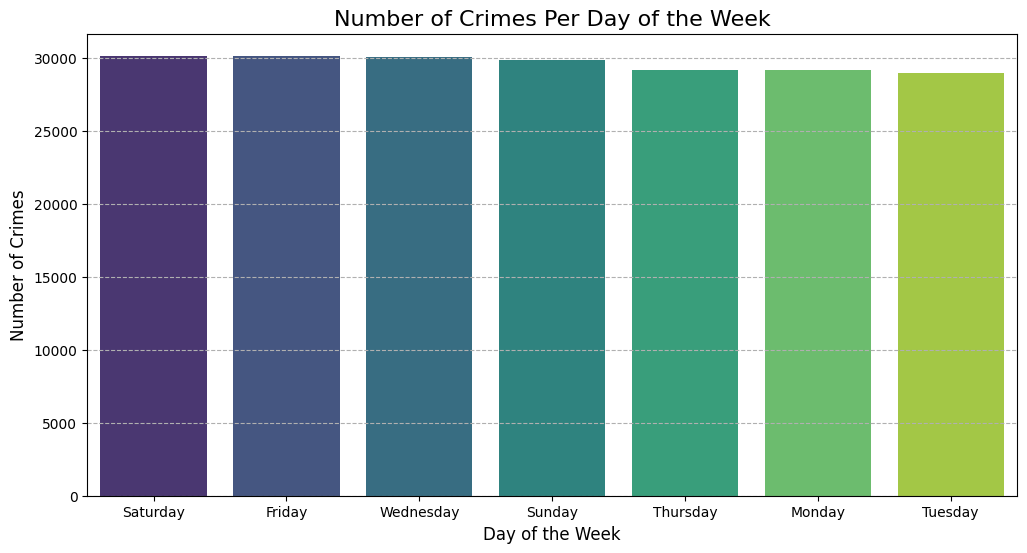

In [23]:
df['DayOfWeek'] = pd.to_datetime(df['Date']).dt.day_name()
crime_by_day = df['DayOfWeek'].value_counts()
plt.figure(figsize=(12, 6))
sns.barplot(x=crime_by_day.index, y=crime_by_day.values, palette='viridis')
plt.title('Number of Crimes Per Day of the Week', fontsize=16)
plt.xlabel('Day of the Week', fontsize=12)
plt.ylabel('Number of Crimes', fontsize=12)
plt.grid(axis='y', linestyle='--')
plt.show()

### Number of Crimes by Hour

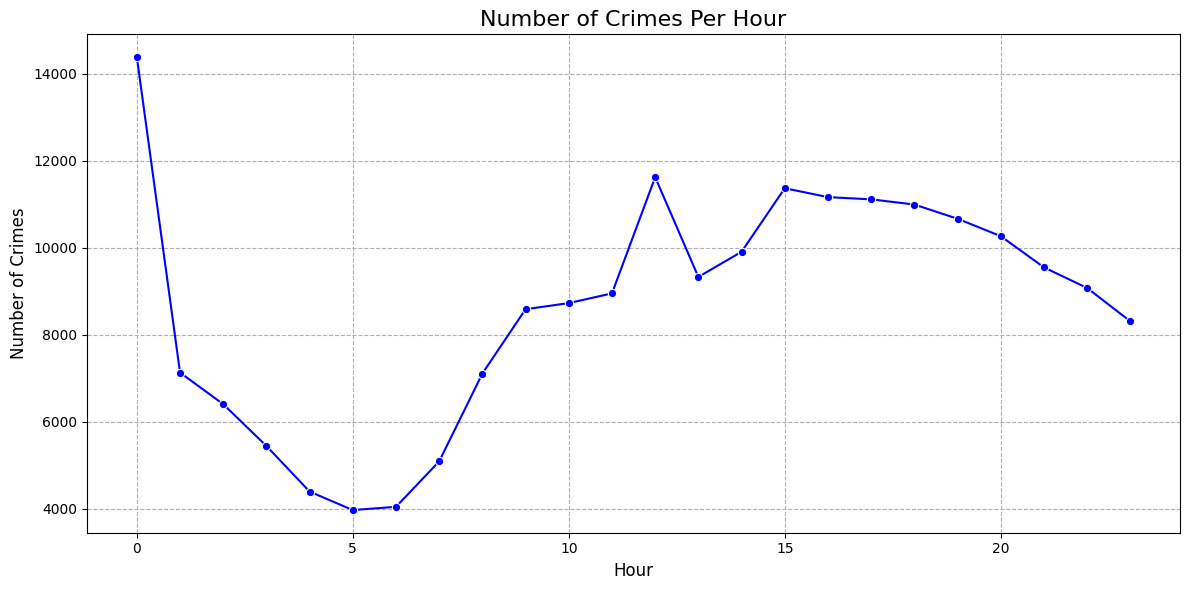

In [25]:
crime_by_hour = df.groupby('Hour').size()
plt.figure(figsize=(12, 6))
sns.lineplot(data=crime_by_hour.reset_index(name='Count'), x='Hour', y='Count', marker='o', color='blue')
plt.title("Number of Crimes Per Hour", fontsize=16)
plt.xlabel("Hour", fontsize=12)
plt.ylabel("Number of Crimes", fontsize=12)
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.show()

### Crimes Types by Hour


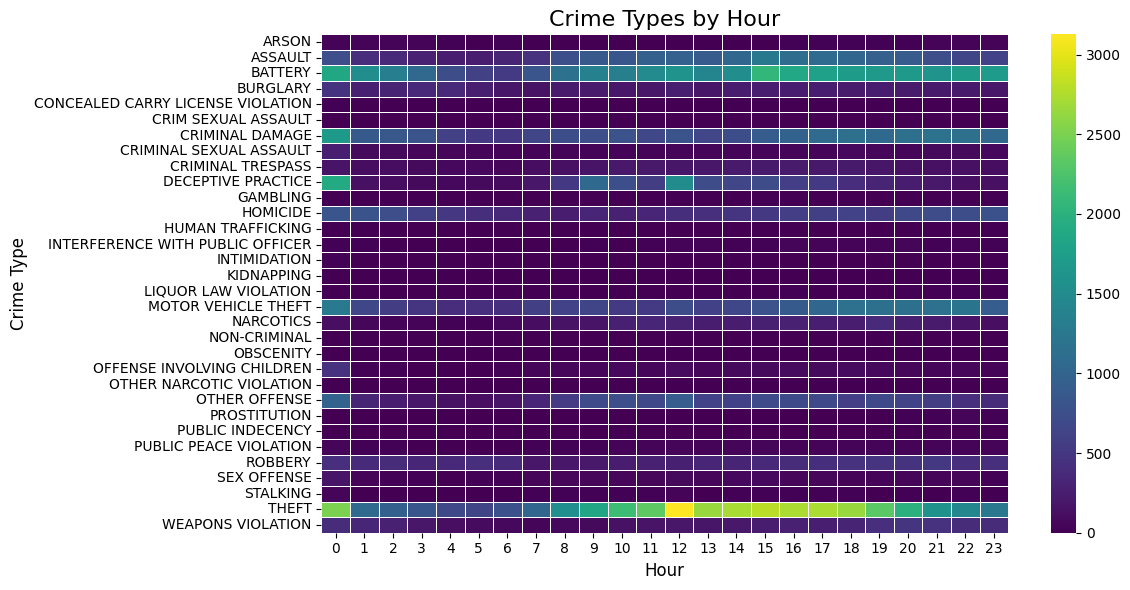

In [26]:
hourly_crime_type = df.groupby(['Hour', 'Primary Type']).size().unstack(fill_value=0)
plt.figure(figsize=(12, 6))
sns.heatmap(hourly_crime_type.T,cmap="viridis",linewidths=0.5,linecolor='white')
plt.title("Crime Types by Hour", fontsize=16)
plt.xlabel("Hour", fontsize=12)
plt.ylabel("Crime Type", fontsize=12)
plt.tight_layout()
plt.show()